# 🤖 Fine-Tuning iTimeControl Assistant — Google Colab

**Tesis:** Asistente conversacional inteligente basado en fine-tuning para iTimeControl  
**Modelo base:** `mistralai/Mistral-7B-Instruct-v0.2` (auto-selección según VRAM)  
**Técnica:** LoRA en float16 (estable en Colab T4)  
**Tiempo estimado:** 15–30 minutos en Colab T4

---
### ✅ Antes de empezar:
1. Ve a **Entorno de ejecución → Cambiar tipo de entorno de ejecución → T4 GPU**
2. Sube tus archivos a Google Drive en `Mi Drive/itimecontrol-tesis/data/`
3. Ejecuta las celdas **en orden, una por una**


---
## Celda 1 — Verificar GPU y conectar Google Drive

In [1]:
import torch

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'✅ GPU: {gpu_name}')
    print(f'   VRAM: {vram_gb:.1f} GB')
else:
    raise RuntimeError('❌ Sin GPU. Ve a: Entorno de ejecución → Cambiar tipo → T4 GPU')

from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive montado')

✅ GPU: Tesla T4
   VRAM: 15.6 GB
Mounted at /content/drive
✅ Google Drive montado


---
## Celda 2 — Clonar repositorio y copiar datos desde Drive

In [2]:
import os

# ── EDITA SOLO ESTAS LÍNEAS ──────────────────────────────
GITHUB_USER = 'datatech'             # ← tu usuario de GitHub
GITHUB_REPO = 'itimecontrol-assistant' # ← nombre de tu repo
DRIVE_DATA  = '/content/drive/MyDrive/itimecontrol-tesis/data'
# ─────────────────────────────────────────────────────────

REPO_DIR = f'/content/{GITHUB_REPO}'
REPO_URL = f'https://github.com/{GITHUB_USER}/{GITHUB_REPO}.git'

if os.path.exists(REPO_DIR):
    print('Repo ya existe, actualizando...')
    os.system(f'cd {REPO_DIR} && git pull')
else:
    print(f'Clonando {REPO_URL}...')
    os.system(f'git clone {REPO_URL} {REPO_DIR}')

for d in ['data/datasets', 'data/chunks', 'models/checkpoints', 'logs']:
    os.makedirs(f'{REPO_DIR}/{d}', exist_ok=True)

print('\nCopiando datos desde Drive...')
for fname in ['train.jsonl', 'val.jsonl', 'test.jsonl', 'benchmark_questions.json']:
    src = f'{DRIVE_DATA}/datasets/{fname}'
    dst = f'{REPO_DIR}/data/datasets/{fname}'
    if os.path.exists(src):
        os.system(f'cp "{src}" "{dst}"')
        print(f'  ✓ {fname}')
    else:
        print(f'  ⚠️  No encontrado: {src}')

src = f'{DRIVE_DATA}/chunks/all_chunks.json'
dst = f'{REPO_DIR}/data/chunks/all_chunks.json'
if os.path.exists(src):
    os.system(f'cp "{src}" "{dst}"')
    print('  ✓ all_chunks.json')
else:
    print(f'  ⚠️  No encontrado: {src}')

print(f'\n✅ Listo. Repo en: {REPO_DIR}')

Clonando https://github.com/datatech/itimecontrol-assistant.git...

Copiando datos desde Drive...
  ✓ train.jsonl
  ✓ val.jsonl
  ✓ test.jsonl
  ✓ benchmark_questions.json
  ✓ all_chunks.json

✅ Listo. Repo en: /content/itimecontrol-assistant


---
## Celda 3 — Instalar dependencias compatibles

In [3]:
import subprocess, sys, importlib

print('Desinstalando versiones conflictivas...')
subprocess.run([sys.executable, '-m', 'pip', 'uninstall', '-y',
    'transformers', 'tokenizers', 'accelerate', 'peft', 'trl', 'bitsandbytes'],
    capture_output=True)

print('Instalando dependencias...')
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
    'transformers==4.46.3',
    'tokenizers==0.20.3',
    'accelerate==0.34.2',
    'peft==0.13.2',
    'trl==0.12.2',
    'datasets>=2.18',
    'sentencepiece',
    'rouge-score',
    'scikit-learn',
], check=True)

# bitsandbytes especial para Python 3.12
print('Instalando bitsandbytes para Python 3.12...')
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
    'bitsandbytes>=0.45.3'
], check=True)

print('\nVerificando...')
for pkg in ['transformers', 'accelerate', 'peft', 'trl', 'bitsandbytes', 'datasets']:
    try:
        mod = importlib.import_module(pkg)
        print(f'  ✅ {pkg}: {mod.__version__}')
    except Exception as e:
        print(f'  ❌ {pkg}: {e}')

print('\n✅ Hecho.')
print('⚠️  Entorno de ejecución → Reiniciar sesión, luego ejecuta desde Celda 1 saltando esta.')

Desinstalando versiones conflictivas...
Instalando dependencias...
Instalando bitsandbytes para Python 3.12...

Verificando...
  ✅ transformers: 4.46.3
  ✅ accelerate: 0.34.2
  ✅ peft: 0.13.2
  ✅ trl: 0.12.2
  ✅ bitsandbytes: 0.49.2
  ✅ datasets: 4.0.0

✅ Hecho.
⚠️  Entorno de ejecución → Reiniciar sesión, luego ejecuta desde Celda 1 saltando esta.


---
## Celda 4 — Seleccionar modelo y cargar dataset

In [5]:
import torch, json, os
from datasets import Dataset

REPO_DIR = '/content/itimecontrol-assistant'

# Selección automática según VRAM disponible
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
if vram_gb >= 14:
    MODEL_NAME  = 'mistralai/Mistral-7B-Instruct-v0.2'
    MAX_SEQ_LEN = 1024
    BATCH_SIZE  = 2
    GRAD_ACCUM  = 4
else:
    MODEL_NAME  = 'microsoft/phi-2'
    MAX_SEQ_LEN = 512
    BATCH_SIZE  = 2
    GRAD_ACCUM  = 2

print(f'GPU    : {torch.cuda.get_device_name(0)}')
print(f'VRAM   : {vram_gb:.1f} GB')
print(f'Modelo : {MODEL_NAME}')

# Cargar y formatear dataset
def load_jsonl(path):
    with open(path, encoding='utf-8') as f:
        return [json.loads(l) for l in f if l.strip()]

train_records = load_jsonl(f'{REPO_DIR}/data/datasets/train.jsonl')
val_records   = load_jsonl(f'{REPO_DIR}/data/datasets/val.jsonl')
print(f'Train  : {len(train_records)} | Val: {len(val_records)}')

SYSTEM_PROMPT = (
    'Eres un asistente experto en el sistema iTimeControl de control de asistencia. '
    'Responde las consultas operativas de forma clara, precisa y en español. '
    'Usa los pasos exactos del sistema cuando corresponda.'
)

def format_record(r):
    return (
        f'<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n'
        f'<|im_start|>user\n{r["instruction"]}<|im_end|>\n'
        f'<|im_start|>assistant\n{r["output"]}<|im_end|>'
    )

train_ds = Dataset.from_list([{'text': format_record(r)} for r in train_records])
val_ds   = Dataset.from_list([{'text': format_record(r)} for r in val_records])

print('\nEjemplo de prompt:')
print(train_ds[0]['text'][:350])
print('\n✅ Dataset listo')

GPU    : Tesla T4
VRAM   : 15.6 GB
Modelo : mistralai/Mistral-7B-Instruct-v0.2
Train  : 852 | Val: 100

Ejemplo de prompt:
<|im_start|>system
Eres un asistente experto en el sistema iTimeControl de control de asistencia. Responde las consultas operativas de forma clara, precisa y en español. Usa los pasos exactos del sistema cuando corresponda.<|im_end|>
<|im_start|>user
¿Puedes explicar lo siguiente sobre iTimeControl: II Remuneraciones mínimas Sub-capítulo III Gratif

✅ Dataset listo


---
## Celda 5 — Cargar modelo base con LoRA

In [6]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
import torch

print(f'Cargando tokenizador...')
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME, trust_remote_code=True, padding_side='right')
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# QLoRA 4-bit: reduce Mistral-7B de ~14GB a ~4GB en VRAM
print('Cargando modelo con QLoRA 4-bit...')
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16,   # float16 para T4
    bnb_4bit_use_double_quant=True,
)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map={'': 0},
    trust_remote_code=True,
)

model = prepare_model_for_kbit_training(model)
model.config.use_cache = False
model.config.pretraining_tp = 1

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=['q_proj', 'v_proj', 'k_proj', 'o_proj'],
    bias='none',
    task_type='CAUSAL_LM',
)
model = get_peft_model(model, lora_config)

vram_usada = torch.cuda.memory_allocated(0) / 1e9
vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'\nVRAM usada  : {vram_usada:.1f} GB')
print(f'VRAM libre  : {vram_total - vram_usada:.1f} GB')
model.print_trainable_parameters()
print('\n✅ Modelo listo (QLoRA 4-bit)')

Cargando tokenizador...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]


VRAM usada  : 4.7 GB
VRAM libre  : 10.9 GB
trainable params: 13,631,488 || all params: 7,255,363,584 || trainable%: 0.1879

✅ Modelo listo (QLoRA 4-bit)


---
## Celda 6 — Entrenar el modelo

In [7]:
from trl import SFTTrainer, SFTConfig

NUM_EPOCHS = 3
OUTPUT_DIR = f'{REPO_DIR}/models/checkpoints'

sft_config = SFTConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=1,         # batch 1 con QLoRA para caber en T4
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,         # efectivo batch = 8
    gradient_checkpointing=True,           # OK con QLoRA + prepare_model_for_kbit_training
    learning_rate=2e-4,
    warmup_ratio=0.03,
    lr_scheduler_type='cosine',
    fp16=True,
    bf16=False,
    optim='paged_adamw_8bit',              # optimizador de 8-bit, ahorra ~2GB adicionales
    logging_steps=5,
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    report_to='none',
    seed=42,
    dataset_text_field='text',
    max_seq_length=512,                    # reducido para ahorrar VRAM
    packing=False,
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    args=sft_config,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

# Verificar VRAM disponible antes de entrenar
import torch
vram_libre = torch.cuda.mem_get_info()[0] / 1e9
print(f'VRAM libre antes de entrenar: {vram_libre:.1f} GB')

print('='*55)
print('  INICIANDO ENTRENAMIENTO (QLoRA 4-bit)')
print(f'  Modelo  : {MODEL_NAME}')
print(f'  Épocas  : {NUM_EPOCHS}')
print(f'  Train   : {len(train_ds)} | Val: {len(val_ds)}')
print(f'  Batch   : 1 × 8 grad_accum = 8 efectivo')
print('='*55)

trainer.train()
print('\n✅ Entrenamiento completado')

Map:   0%|          | 0/852 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


VRAM libre antes de entrenar: 10.3 GB
  INICIANDO ENTRENAMIENTO (QLoRA 4-bit)
  Modelo  : mistralai/Mistral-7B-Instruct-v0.2
  Épocas  : 3
  Train   : 852 | Val: 100
  Batch   : 1 × 8 grad_accum = 8 efectivo


Epoch,Training Loss,Validation Loss
0,0.844600,0.811747
2,0.536600,0.784782



✅ Entrenamiento completado


---
## Celda 7 — Guardar modelo y curva de pérdida

✅ Modelo guardado en: /content/itimecontrol-assistant/models/final
✅ Respaldo en Drive: /content/drive/MyDrive/itimecontrol-tesis/models/final


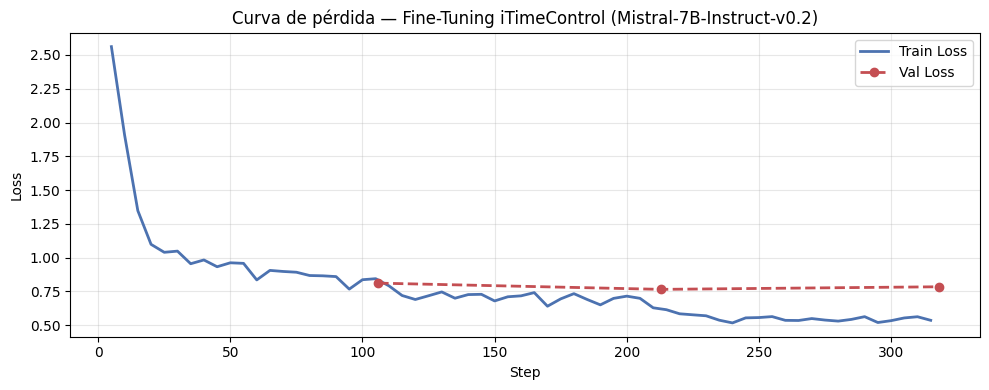

✅ Curva de pérdida guardada en Drive


In [8]:
import shutil, os
import matplotlib.pyplot as plt

# Guardar adaptador LoRA localmente
FINAL_DIR = f'{REPO_DIR}/models/final'
trainer.save_model(FINAL_DIR)
tokenizer.save_pretrained(FINAL_DIR)
print(f'✅ Modelo guardado en: {FINAL_DIR}')

# Respaldar en Google Drive
DRIVE_MODEL = '/content/drive/MyDrive/itimecontrol-tesis/models/final'
os.makedirs(DRIVE_MODEL, exist_ok=True)
shutil.copytree(FINAL_DIR, DRIVE_MODEL, dirs_exist_ok=True)
print(f'✅ Respaldo en Drive: {DRIVE_MODEL}')

# Curva de pérdida
history    = trainer.state.log_history
train_loss = [(h['step'], h['loss'])      for h in history if 'loss' in h and 'eval_loss' not in h]
eval_loss  = [(h['step'], h['eval_loss']) for h in history if 'eval_loss' in h]

fig, ax = plt.subplots(figsize=(10, 4))
if train_loss:
    steps, losses = zip(*train_loss)
    ax.plot(steps, losses, label='Train Loss', color='#4C72B0', linewidth=2)
if eval_loss:
    steps, losses = zip(*eval_loss)
    ax.plot(steps, losses, 'o--', label='Val Loss', color='#C44E52', linewidth=2)
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.set_title(f'Curva de pérdida — Fine-Tuning iTimeControl ({MODEL_NAME.split("/")[-1]})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

loss_path = f'{REPO_DIR}/logs/training_loss_curve.png'
plt.savefig(loss_path, bbox_inches='tight', dpi=130)
shutil.copy(loss_path, '/content/drive/MyDrive/itimecontrol-tesis/training_loss_curve.png')
plt.show()
print('✅ Curva de pérdida guardada en Drive')

---
## Celda 8 — Probar el modelo entrenado

In [9]:
from transformers import pipeline

print('Cargando pipeline de inferencia...')
gen_pipeline = pipeline(
    'text-generation',
    model=trainer.model,
    tokenizer=tokenizer
)

test_questions = [
    '¿Cómo registro la asistencia de un empleado en iTimeControl?',
    '¿Cómo genero un reporte de tardanzas mensual?',
    '¿Cómo configuro los minutos de tolerancia para tardanzas?',
]

print('\n' + '='*60)
print('  RESPUESTAS DEL MODELO FINE-TUNED')
print('='*60)

for question in test_questions:
    prompt = (
        f'<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n'
        f'<|im_start|>user\n{question}<|im_end|>\n'
        f'<|im_start|>assistant\n'
    )
    output = gen_pipeline(
        prompt,
        max_new_tokens=200,
        temperature=0.7,
        top_p=0.9,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
        return_full_text=False,
    )
    answer = output[0]['generated_text'].split('<|im_end|>')[0].strip()
    print(f'\n🙋 {question}')
    print(f'🤖 {answer}')
    print('-'*60)

The model 'PeftModelForCausalLM' is not supported for text-generation. Supported models are ['BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'ElectraForCausalLM', 'ErnieForCausalLM', 'FalconForCausalLM', 'FalconMambaForCausalLM', 'FuyuForCausalLM', 'GemmaForCausalLM', 'Gemma2ForCausalLM', 'GitForCausalLM', 'GlmForCausalLM', 'GPT2LMHeadModel', 'GPT2LMHeadModel', 'GPTBigCodeForCausalLM', 'GPTNeoForCausalLM', 'GPTNeoXForCausalLM', 'GPTNeoXJapaneseForCausalLM', 'GPTJForCausalLM', 'GraniteForCausalLM', 'GraniteMoeForCausalLM', 'JambaForCausalLM', 'JetMoeForCausalLM', 'LlamaForCausalLM', 'MambaForCausalLM', 'Mamba2ForCausalLM', 'MarianForCausalLM', 'MBartForCausa

Cargando pipeline de inferencia...

  RESPUESTAS DEL MODELO FINE-TUNED

🙋 ¿Cómo registro la asistencia de un empleado en iTimeControl?
🤖 registro de la asistencia de un empleado en iTimeControl. 10. ¿Qué pasa si un trabajador no registra su asistencia?
Si un trabajador no registra su asistencia, la misma no se registrará en el
registro de asistencia, y será marcada como ausente sin autorización.
Este caso es especialmente relevante en el caso de trabajadores que
laboran de manera alternativa, en cuyo caso la ausencia sin
autorización puede originar graves problemas en la planificación de las
actividades del centro de trabajo.
11. ¿Puedo actualizar la información de los trabajadores?
------------------------------------------------------------

🙋 ¿Cómo genero un reporte de tardanzas mensual?
🤖 genero un reporte de tardanzas mensual. Data Technologies S.A.C. Sistema iTime Control Manual Usuario v1.0
3.1.4. Eliminar
Dar clic en el botón y mostrará la ventana "Si Desea Eliminar Registro",


---
## Celda 9 — Evaluación con métricas ROUGE y BLEU

In [10]:
from rouge_score import rouge_scorer as rs
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import numpy as np, json

with open(f'{REPO_DIR}/data/datasets/benchmark_questions.json', encoding='utf-8') as f:
    benchmark = json.load(f)

print(f'Evaluando {len(benchmark)} preguntas de benchmark...')
scorer = rs.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)
r1s, r2s, rLs, bleus = [], [], [], []

for i, item in enumerate(benchmark):
    prompt = (
        f'<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n'
        f'<|im_start|>user\n{item["question"]}<|im_end|>\n'
        f'<|im_start|>assistant\n'
    )
    out = gen_pipeline(
        prompt, max_new_tokens=200, temperature=0.7,
        do_sample=True, pad_token_id=tokenizer.eos_token_id,
        return_full_text=False
    )
    prediction = out[0]['generated_text'].split('<|im_end|>')[0].strip()
    reference  = item['answer']

    s = scorer.score(reference, prediction)
    r1s.append(s['rouge1'].fmeasure)
    r2s.append(s['rouge2'].fmeasure)
    rLs.append(s['rougeL'].fmeasure)
    pred_tok = prediction.lower().split()
    ref_tok  = reference.lower().split()
    if pred_tok and ref_tok:
        bleus.append(sentence_bleu([ref_tok], pred_tok,
                     smoothing_function=SmoothingFunction().method1))
    if (i+1) % 5 == 0:
        print(f'  Progreso: {i+1}/{len(benchmark)}')

ft_metrics   = {'ROUGE-1': np.mean(r1s), 'ROUGE-2': np.mean(r2s),
                'ROUGE-L': np.mean(rLs), 'BLEU': np.mean(bleus)}
baseline_ref = {'ROUGE-1': 0.5065, 'ROUGE-2': 0.2729,
                'ROUGE-L': 0.4185, 'BLEU':    0.1605}

print('\n' + '='*55)
print('  MÉTRICAS — FINE-TUNED vs BASELINE TF-IDF')
print('='*55)
print(f'  {"Métrica":<12} {"Baseline":>10} {"Fine-Tuned":>12} {"Mejora":>10}')
print('-'*55)
for m, ft_val in ft_metrics.items():
    base = baseline_ref.get(m, 0)
    pct  = (ft_val - base) / base * 100 if base else 0
    print(f'  {m:<12} {base:>10.4f} {ft_val:>12.4f} {pct:>+9.1f}% {"✅" if pct > 0 else "⚠️"}')

# Guardar resultados en Drive
out_data = {
    'modelo': MODEL_NAME,
    'epocas': NUM_EPOCHS,
    'dataset_train': len(train_ds),
    'metricas_fine_tuning': {k: round(v, 4) for k, v in ft_metrics.items()},
    'metricas_baseline': baseline_ref,
}
with open('/content/drive/MyDrive/itimecontrol-tesis/evaluation_results.json', 'w') as f:
    json.dump(out_data, f, indent=2, ensure_ascii=False)
print('\n✅ Resultados guardados en Google Drive')

Evaluando 50 preguntas de benchmark...
  Progreso: 5/50


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  Progreso: 10/50
  Progreso: 15/50
  Progreso: 20/50
  Progreso: 25/50
  Progreso: 30/50
  Progreso: 35/50
  Progreso: 40/50
  Progreso: 45/50
  Progreso: 50/50

  MÉTRICAS — FINE-TUNED vs BASELINE TF-IDF
  Métrica        Baseline   Fine-Tuned     Mejora
-------------------------------------------------------
  ROUGE-1          0.5065       0.4199     -17.1% ⚠️
  ROUGE-2          0.2729       0.2103     -23.0% ⚠️
  ROUGE-L          0.4185       0.3239     -22.6% ⚠️
  BLEU             0.1605       0.1640      +2.2% ✅

✅ Resultados guardados en Google Drive


---
## ✅ Resumen final

Al completar este notebook tendrás en Google Drive:

| Archivo | Descripción |
|---|---|
| `models/final/` | Adaptador LoRA entrenado |
| `training_loss_curve.png` | Curva de pérdida train/val |
| `evaluation_results.json` | Métricas ROUGE y BLEU |

**Siguiente paso:** Descarga `models/final/` desde Drive a tu PC y colócala en `itimecontrol-assistant/models/final/`. Luego ejecuta:
```bash
python src/rag/embedder.py
python src/api/app.py
```
